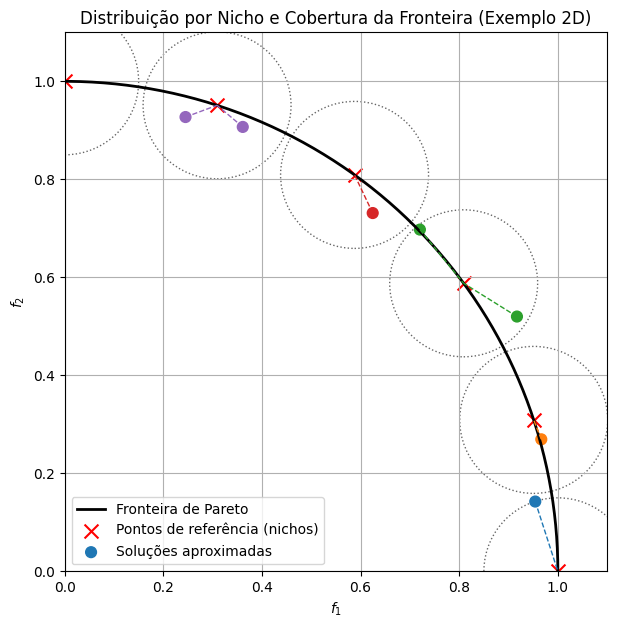

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Fronteira de Pareto (arco de círculo) ---
theta = np.linspace(0, np.pi/2, 200)
pareto_front = np.column_stack([np.cos(theta), np.sin(theta)])

# --- Soluções aproximadas ---
np.random.seed(1)
approx_points = pareto_front[::25] + np.random.normal(0, 0.05, (len(pareto_front[::25]), 2))

# --- Pontos de referência (nichos) ---
ref_theta = np.linspace(0, np.pi/2, 6)  # 6 nichos
ref_points = np.column_stack([np.cos(ref_theta), np.sin(ref_theta)])

# --- Raio de cobertura (ilustrativo) ---
r = 0.15

# --- Associação solução -> nicho ---
assignments = []
for p in approx_points:
    dists = np.linalg.norm(ref_points - p, axis=1)
    assignments.append(np.argmin(dists))

# --- Plot ---
fig, ax = plt.subplots(figsize=(7,7))

# Fronteira
ax.plot(pareto_front[:,0], pareto_front[:,1], 'k-', lw=2, label="Fronteira de Pareto")

# Pontos de referência
ax.scatter(ref_points[:,0], ref_points[:,1], c='red', marker='x', s=100, label="Pontos de referência (nichos)")

# Círculos pontilhados (raio r)
for rp in ref_points:
    circ = plt.Circle(rp, r, color='black', fill=False, linestyle='dotted', alpha=0.6)
    ax.add_patch(circ)

# Aproximações (coloridas por nicho)
colors = plt.cm.tab10(np.array(assignments) % 10)
ax.scatter(approx_points[:,0], approx_points[:,1], c=colors, s=60, label="Soluções aproximadas")

# Linhas de associação
for p, idx, c in zip(approx_points, assignments, colors):
    ax.plot([p[0], ref_points[idx,0]], [p[1], ref_points[idx,1]], '--', color=c, lw=1)

# Estética
ax.set_title("Distribuição por Nicho e Cobertura da Fronteira (Exemplo 2D)")
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$")
ax.set_xlim(0,1.1)
ax.set_ylim(0,1.1)
ax.legend(loc="lower left")
ax.grid(True)
plt.show()
